# MNIST Generation via MoG Reservoir + Linear Readout

Dependencies: `jax`, `optax`, `numpy`, `matplotlib` only.

1. Load MNIST 0s and 1s (raw download, no frameworks)
2. PCA to low-dimensional space (numpy SVD)
3. Random mixture of Gaussians reservoir in $\mathbb{R}^D$
4. Learn linear readout $y = Ax + b$ via MMD
5. Map back to pixel space via inverse PCA

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
from jax import jit
import optax
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import gzip
import struct
import os

print(f"JAX devices: {jax.devices()}")

JAX devices: [CpuDevice(id=0)]


## 1. Load MNIST (raw download, no frameworks)

Total 0s and 1s: 14780
  0s: 6903, 1s: 7877


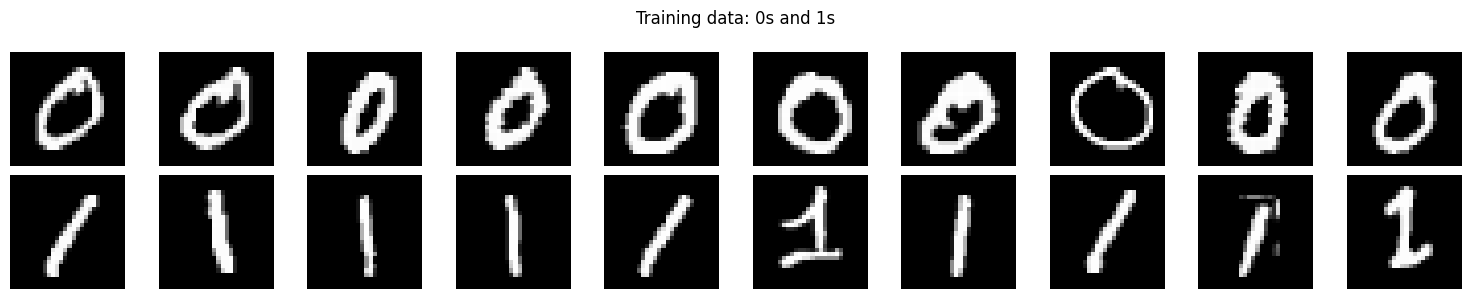

In [2]:
def download_mnist(data_dir='./mnist_data'):
    """Download and parse MNIST from raw gzip files."""
    os.makedirs(data_dir, exist_ok=True)
    base_url = 'https://storage.googleapis.com/cvdf-datasets/mnist/'
    files = {
        'train_images': 'train-images-idx3-ubyte.gz',
        'train_labels': 'train-labels-idx1-ubyte.gz',
        'test_images':  't10k-images-idx3-ubyte.gz',
        'test_labels':  't10k-labels-idx1-ubyte.gz',
    }
    
    for key, fname in files.items():
        fpath = os.path.join(data_dir, fname)
        if not os.path.exists(fpath):
            print(f'Downloading {fname}...')
            urllib.request.urlretrieve(base_url + fname, fpath)
    
    def read_images(fpath):
        with gzip.open(fpath, 'rb') as f:
            magic, num, rows, cols = struct.unpack('>IIII', f.read(16))
            return np.frombuffer(f.read(), dtype=np.uint8).reshape(num, rows * cols)
    
    def read_labels(fpath):
        with gzip.open(fpath, 'rb') as f:
            magic, num = struct.unpack('>II', f.read(8))
            return np.frombuffer(f.read(), dtype=np.uint8)
    
    x_train = read_images(os.path.join(data_dir, files['train_images']))
    y_train = read_labels(os.path.join(data_dir, files['train_labels']))
    x_test  = read_images(os.path.join(data_dir, files['test_images']))
    y_test  = read_labels(os.path.join(data_dir, files['test_labels']))
    
    x_all = np.concatenate([x_train, x_test]).astype(np.float32) / 255.0
    y_all = np.concatenate([y_train, y_test])
    return x_all, y_all


x_all, y_all = download_mnist()

# filter 0s and 1s
mask = (y_all == 0) | (y_all == 1)
x_01 = x_all[mask]
y_01 = y_all[mask]

print(f"Total 0s and 1s: {x_01.shape[0]}")
print(f"  0s: {(y_01 == 0).sum()}, 1s: {(y_01 == 1).sum()}")

# show some examples
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
    axes[0, i].imshow(x_01[y_01 == 0][i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_01[y_01 == 1][i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('0s'); axes[1, 0].set_ylabel('1s')
plt.suptitle('Training data: 0s and 1s')
plt.tight_layout(); plt.show()

## 2. PCA via numpy SVD

PCA to 30 dims: 85.2% variance explained


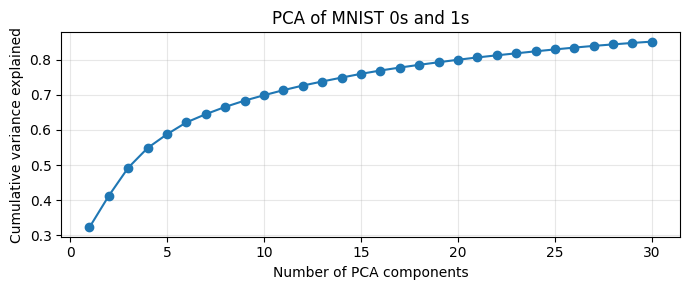

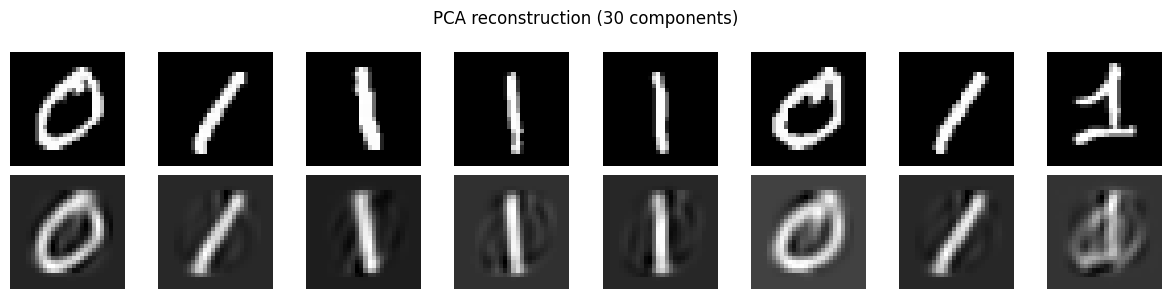

Target data in PCA space: (14780, 30)


In [3]:
class SimplePCA:
    """PCA using numpy SVD. No sklearn needed."""
    
    def __init__(self, n_components):
        self.n_components = n_components
    
    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        X_centered = X - self.mean_
        U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
        self.components_ = Vt[:self.n_components]
        self.singular_values_ = S[:self.n_components]
        total_var = np.sum(S ** 2)
        self.explained_variance_ratio_ = (S[:self.n_components] ** 2) / total_var
        return self
    
    def transform(self, X):
        return (X - self.mean_) @ self.components_.T
    
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)
    
    def inverse_transform(self, Z):
        return Z @ self.components_ + self.mean_


N_PCA = 30  # try 20, 30, 50

pca = SimplePCA(n_components=N_PCA)
x_pca = pca.fit_transform(x_01)

explained = np.cumsum(pca.explained_variance_ratio_)
print(f"PCA to {N_PCA} dims: {explained[-1]*100:.1f}% variance explained")

# plot explained variance
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(range(1, N_PCA+1), explained, 'o-')
ax.set_xlabel('Number of PCA components')
ax.set_ylabel('Cumulative variance explained')
ax.set_title('PCA of MNIST 0s and 1s')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# verify reconstruction
x_recon = pca.inverse_transform(x_pca)
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    axes[0, i].imshow(x_01[i].reshape(28, 28), cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(x_recon[i].reshape(28, 28), cmap='gray'); axes[1, i].axis('off')
axes[0, 0].set_ylabel('Orig'); axes[1, 0].set_ylabel('Recon')
plt.suptitle(f'PCA reconstruction ({N_PCA} components)')
plt.tight_layout(); plt.show()

print(f"Target data in PCA space: {x_pca.shape}")

## 3. Configuration

In [4]:
M = N_PCA

# reservoir
D = 30
K = 2
MEAN_RADIUS = 5.0
COV_SCALE = 0.5

# training
N_RESERVOIR = 4096
N_TARGET = min(4096, x_pca.shape[0])
LEARNING_RATE = 5e-3
LR_END_RATIO = 1e-2
N_STEPS = 8000
BATCH_SIZE = 512
LOG_EVERY = 1000

# kernel bandwidths via median heuristic (no scipy)
rng_np = np.random.RandomState(0)
subset = x_pca[rng_np.choice(len(x_pca), 500, replace=False)]
diff = subset[:, None, :] - subset[None, :, :]
pw_dists = np.sqrt(np.sum(diff**2, axis=-1))
median_dist = np.median(pw_dists[np.triu_indices(len(subset), k=1)])
print(f"Median pairwise distance in PCA space: {median_dist:.2f}")

SIGMAS = [median_dist * f for f in [0.1, 0.25, 0.5, 1.0, 2.0]]
print(f"Kernel bandwidths: {[f'{s:.2f}' for s in SIGMAS]}")

Median pairwise distance in PCA space: 9.28
Kernel bandwidths: ['0.93', '2.32', '4.64', '9.28', '18.55']


## 4. MoG Reservoir

In [5]:
def init_reservoir_mog(key, D, K, mean_radius, cov_scale):
    k1, k2, k3 = jr.split(key, 3)
    directions = jr.normal(k1, (K, D))
    directions = directions / jnp.linalg.norm(directions, axis=1, keepdims=True)
    radii = jr.uniform(k2, (K, 1), minval=0.0, maxval=mean_radius)
    means = directions * radii
    
    factors = jr.normal(k3, (K, D, D)) * cov_scale / jnp.sqrt(D)
    covs = jnp.einsum('kij,klj->kil', factors, factors)
    covs = covs + 0.01 * jnp.eye(D)[None, :, :]
    Ls = jnp.linalg.cholesky(covs)
    return {'means': means, 'Ls': Ls, 'K': K, 'D': D}


def sample_reservoir(key, reservoir, n_samples):
    means = reservoir['means']
    Ls = reservoir['Ls']
    K = reservoir['K']
    D = reservoir['D']
    k1, k2 = jr.split(key)
    assignments = jr.choice(k1, K, shape=(n_samples,))
    eps = jr.normal(k2, (n_samples, D))
    samples = jnp.zeros((n_samples, D))
    for k in range(K):
        mask = (assignments == k)[:, None]
        samples = samples + mask * (eps @ Ls[k].T + means[k])
    return samples


reservoir = init_reservoir_mog(jr.PRNGKey(42), D, K, MEAN_RADIUS, COV_SCALE)
print(f"Reservoir: {K} components in R^{D}")

Reservoir: 2 components in R^30


## 5. Target samples

In [6]:
idx_target = rng_np.choice(len(x_pca), N_TARGET, replace=False)
target_samples = jnp.array(x_pca[idx_target])
target_labels = y_01[idx_target]
print(f"Target samples: {target_samples.shape}")

Target samples: (4096, 30)


## 6. MMD loss and readout

In [7]:
def mmd_squared(P, Q, sigma):
    n, m = P.shape[0], Q.shape[0]
    two_s2 = 2.0 * sigma ** 2
    def sq_dists(X, Y):
        return (jnp.sum(X**2, axis=1, keepdims=True)
                - 2.0 * X @ Y.T
                + jnp.sum(Y**2, axis=1))
    K_pp = jnp.exp(-sq_dists(P, P) / two_s2)
    K_qq = jnp.exp(-sq_dists(Q, Q) / two_s2)
    K_pq = jnp.exp(-sq_dists(P, Q) / two_s2)
    t_pp = (jnp.sum(K_pp) - jnp.trace(K_pp)) / (n * (n - 1))
    t_qq = (jnp.sum(K_qq) - jnp.trace(K_qq)) / (m * (m - 1))
    t_pq = jnp.sum(K_pq) / (n * m)
    return t_pp - 2.0 * t_pq + t_qq


def mmd_multi(P, Q, sigmas):
    return sum(mmd_squared(P, Q, s) for s in sigmas)


def init_readout(key, M, D):
    k1, _ = jr.split(key)
    A = jr.normal(k1, (M, D)) * 0.01
    b = jnp.zeros(M)
    return {'A': A, 'b': b}


def readout(params, X):
    return X @ params['A'].T + params['b']


def loss_fn(readout_params, res_batch, tgt_batch, sigmas):
    Y = readout(readout_params, res_batch)
    return mmd_multi(Y, tgt_batch, sigmas)

## 7. Training

In [8]:
readout_params = init_readout(jr.PRNGKey(45), M, D)

schedule = optax.cosine_decay_schedule(
    init_value=LEARNING_RATE,
    decay_steps=N_STEPS,
    alpha=LR_END_RATIO,
)
optimizer = optax.adam(schedule)
opt_state = optimizer.init(readout_params)


@jit
def train_step(params, opt_state, res_batch, tgt_batch):
    loss, grads = jax.value_and_grad(loss_fn)(params, res_batch, tgt_batch, SIGMAS)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss


losses = []
rng = jr.PRNGKey(0)

for step in range(N_STEPS):
    rng, k1, k2 = jr.split(rng, 3)
    res_fresh = sample_reservoir(k1, reservoir, BATCH_SIZE)
    idx_t = jr.choice(k2, N_TARGET, shape=(BATCH_SIZE,), replace=False)
    
    readout_params, opt_state, loss = train_step(
        readout_params, opt_state,
        res_fresh, target_samples[idx_t]
    )
    losses.append(float(loss))
    
    if step % LOG_EVERY == 0 or step == N_STEPS - 1:
        print(f"step {step:5d}  MMD² = {loss:.6f}")

print("Done.")

step     0  MMD² = 2.404017
step  1000  MMD² = 0.024587
step  2000  MMD² = 0.016536
step  3000  MMD² = 0.017929
step  4000  MMD² = 0.026223
step  5000  MMD² = 0.011882
step  6000  MMD² = 0.017954
step  7000  MMD² = 0.012380
step  7999  MMD² = 0.011750
Done.


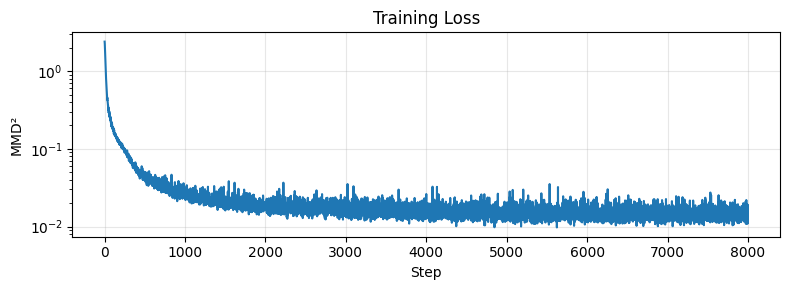

In [9]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogy(losses)
ax.set_xlabel('Step'); ax.set_ylabel('MMD²')
ax.set_title('Training Loss'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 8. Generate and visualize

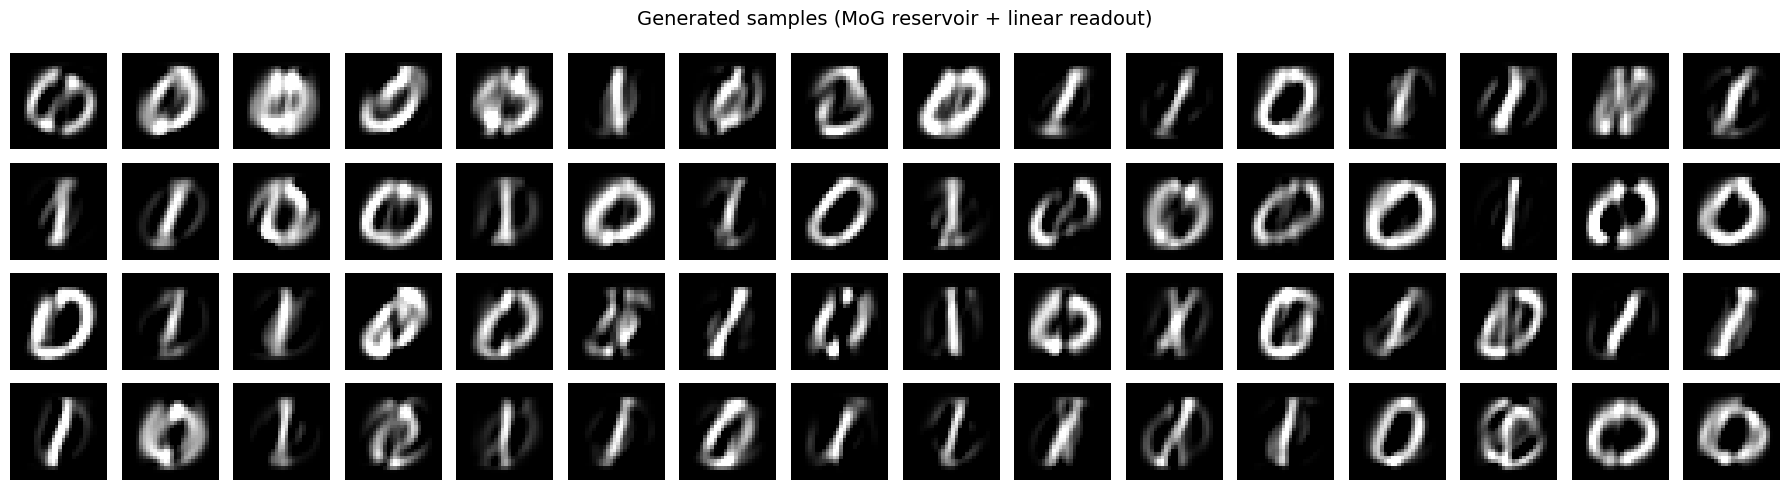

In [10]:
N_GEN = 64
gen_reservoir = sample_reservoir(jr.PRNGKey(99), reservoir, N_GEN)
gen_pca = readout(readout_params, gen_reservoir)
gen_pixels = np.clip(pca.inverse_transform(np.array(gen_pca)), 0, 1)

fig, axes = plt.subplots(4, 16, figsize=(18, 5))
for i in range(64):
    r, c = i // 16, i % 16
    axes[r, c].imshow(gen_pixels[i].reshape(28, 28), cmap='gray')
    axes[r, c].axis('off')
plt.suptitle('Generated samples (MoG reservoir + linear readout)', fontsize=14)
plt.tight_layout()
plt.savefig('mnist_generated.png', dpi=150, bbox_inches='tight')
plt.show()

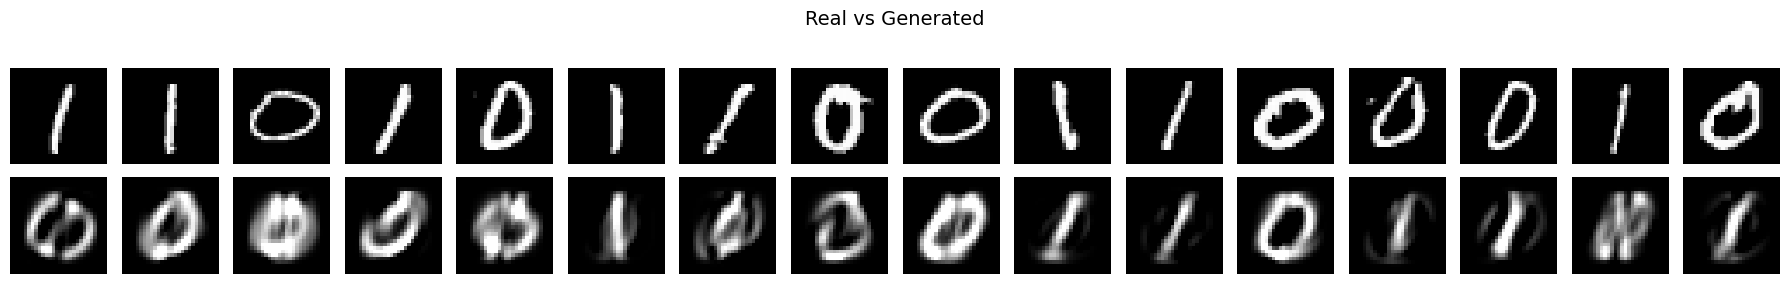

In [11]:
# side-by-side: real vs generated
fig, axes = plt.subplots(2, 16, figsize=(18, 3))
real_idx = rng_np.choice(len(x_01), 16, replace=False)
for i in range(16):
    axes[0, i].imshow(x_01[real_idx[i]].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(gen_pixels[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('Real', fontsize=12)
axes[1, 0].set_ylabel('Gen', fontsize=12)
plt.suptitle('Real vs Generated', fontsize=14)
plt.tight_layout()
plt.savefig('mnist_real_vs_gen.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Analysis in PCA space

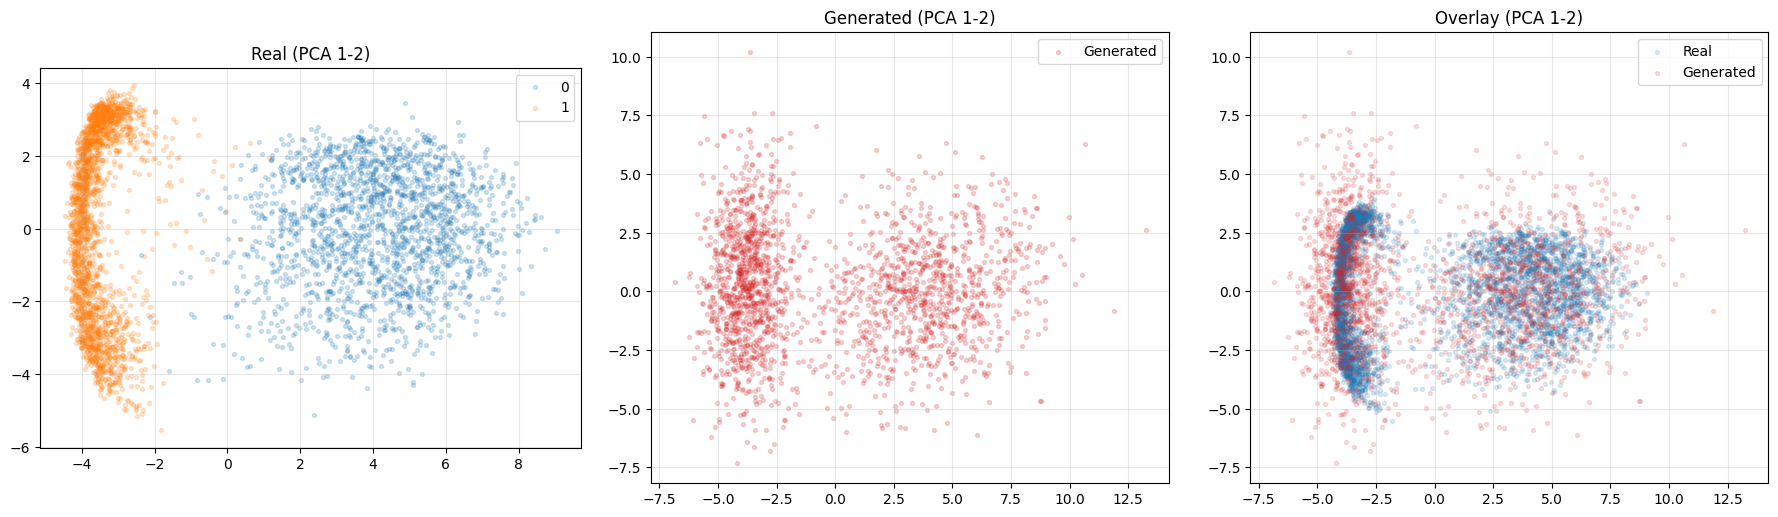

In [12]:
gen_pca_large = np.array(readout(readout_params,
    sample_reservoir(jr.PRNGKey(200), reservoir, 2048)))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# real, colored by digit
ax = axes[0]
for digit, color, label in [(0, 'tab:blue', '0'), (1, 'tab:orange', '1')]:
    mask_d = target_labels == digit
    ax.scatter(np.array(target_samples[mask_d, 0]),
              np.array(target_samples[mask_d, 1]),
              alpha=0.2, s=8, c=color, label=label)
ax.set_title('Real (PCA 1-2)'); ax.legend(); ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# generated
ax = axes[1]
ax.scatter(gen_pca_large[:, 0], gen_pca_large[:, 1],
          alpha=0.2, s=8, c='tab:red', label='Generated')
ax.set_title('Generated (PCA 1-2)'); ax.legend(); ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# overlay
ax = axes[2]
ax.scatter(np.array(target_samples[:, 0]), np.array(target_samples[:, 1]),
          alpha=0.15, s=8, c='tab:blue', label='Real')
ax.scatter(gen_pca_large[:, 0], gen_pca_large[:, 1],
          alpha=0.15, s=8, c='tab:red', label='Generated')
ax.set_title('Overlay (PCA 1-2)'); ax.legend(); ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mnist_pca_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

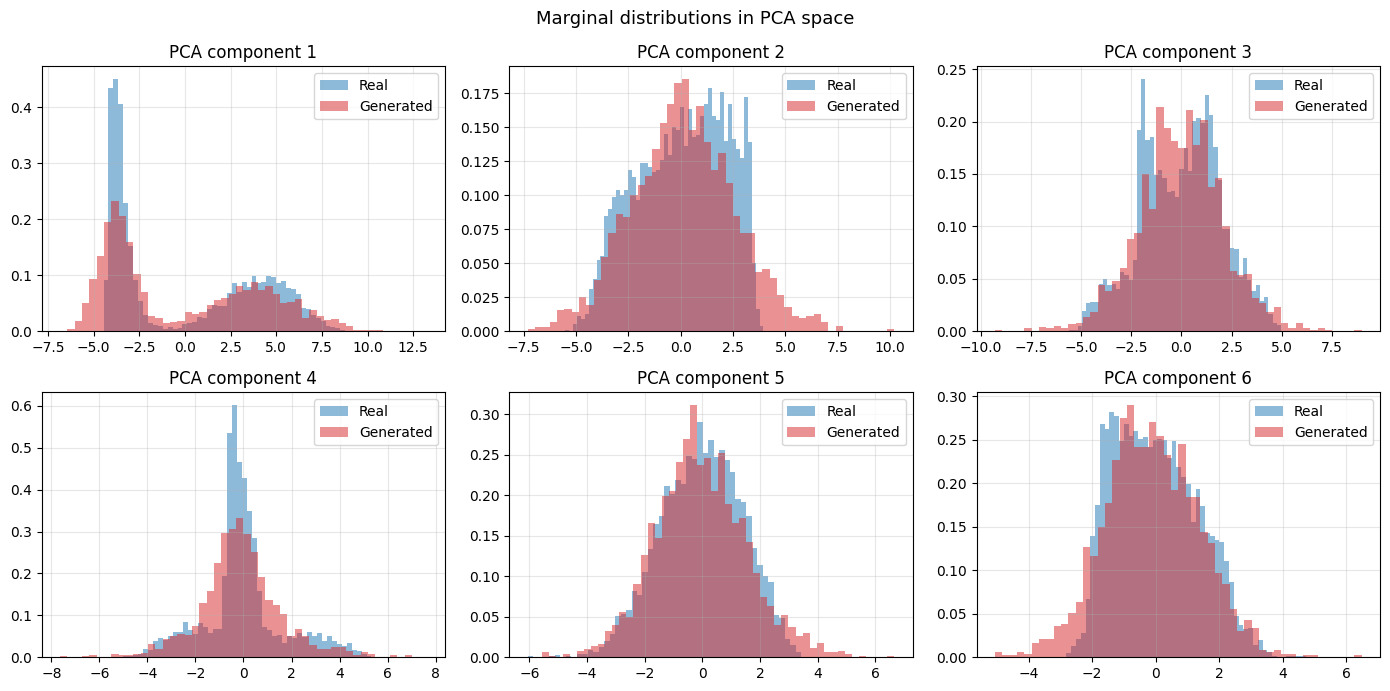

In [13]:
# marginal distributions along first few PCA components
n_show = min(6, M)
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    if i >= n_show:
        ax.axis('off'); continue
    ax.hist(np.array(target_samples[:, i]), bins=50, density=True,
            alpha=0.5, color='tab:blue', label='Real')
    ax.hist(gen_pca_large[:, i], bins=50, density=True,
            alpha=0.5, color='tab:red', label='Generated')
    ax.set_title(f'PCA component {i+1}')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('Marginal distributions in PCA space', fontsize=13)
plt.tight_layout()
plt.savefig('mnist_pca_marginals.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Sweep: D, K

In [14]:
def run_mnist_experiment(D, K, key, n_steps=10000):
    k1, k2, k3 = jr.split(key, 3)
    res = init_reservoir_mog(k1, D, K, MEAN_RADIUS, COV_SCALE)
    ro = init_readout(k2, M, D)
    
    sched = optax.cosine_decay_schedule(
        init_value=LEARNING_RATE, decay_steps=n_steps, alpha=LR_END_RATIO
    )
    opt = optax.adam(sched)
    ost = opt.init(ro)
    
    @jit
    def step(ro, ost, rb, tb):
        l, g = jax.value_and_grad(loss_fn)(ro, rb, tb, SIGMAS)
        u, ost = opt.update(g, ost, ro)
        ro = optax.apply_updates(ro, u)
        return ro, ost, l
    
    rng = k3
    tail = []
    for s in range(n_steps):
        rng, rk1, rk2 = jr.split(rng, 3)
        rb = sample_reservoir(rk1, res, BATCH_SIZE)
        tb = target_samples[jr.choice(rk2, N_TARGET, shape=(BATCH_SIZE,), replace=False)]
        ro, ost, l = step(ro, ost, rb, tb)
        if s >= n_steps - 200:
            tail.append(float(l))
    
    gen = readout(ro, sample_reservoir(jr.PRNGKey(999), res, 16))
    gen_img = np.clip(pca.inverse_transform(np.array(gen)), 0, 1)
    return np.mean(tail), gen_img


configs = [
    (50,  2),
    (100,  2),
    (200,  2),
    (400,  2),
    (50,  4),
    (100,  4),
    (200,  4),
    (400,  4),
    (50,  6),
    (100,  6),
    (200,  6),
    (400,  6),
    
]

sweep_results = {}
sweep_key = jr.PRNGKey(77)

for D_s, K_s in configs:
    sweep_key, sk = jr.split(sweep_key)
    fl, gen_img = run_mnist_experiment(D_s, K_s, sk)
    sweep_results[(D_s, K_s)] = (fl, gen_img)
    print(f"D={D_s:4d}  K={K_s:4d}  =>  MMD² = {fl:.6f}")

D=  50  K=   2  =>  MMD² = 0.011682
D= 100  K=   2  =>  MMD² = 0.010764
D= 200  K=   2  =>  MMD² = 0.010769
D= 400  K=   2  =>  MMD² = 0.010928
D=  50  K=   4  =>  MMD² = 0.011271
D= 100  K=   4  =>  MMD² = 0.009536
D= 200  K=   4  =>  MMD² = 0.009899
D= 400  K=   4  =>  MMD² = 0.012190
D=  50  K=   6  =>  MMD² = 0.021863
D= 100  K=   6  =>  MMD² = 0.008661
D= 200  K=   6  =>  MMD² = 0.014890
D= 400  K=   6  =>  MMD² = 0.008403


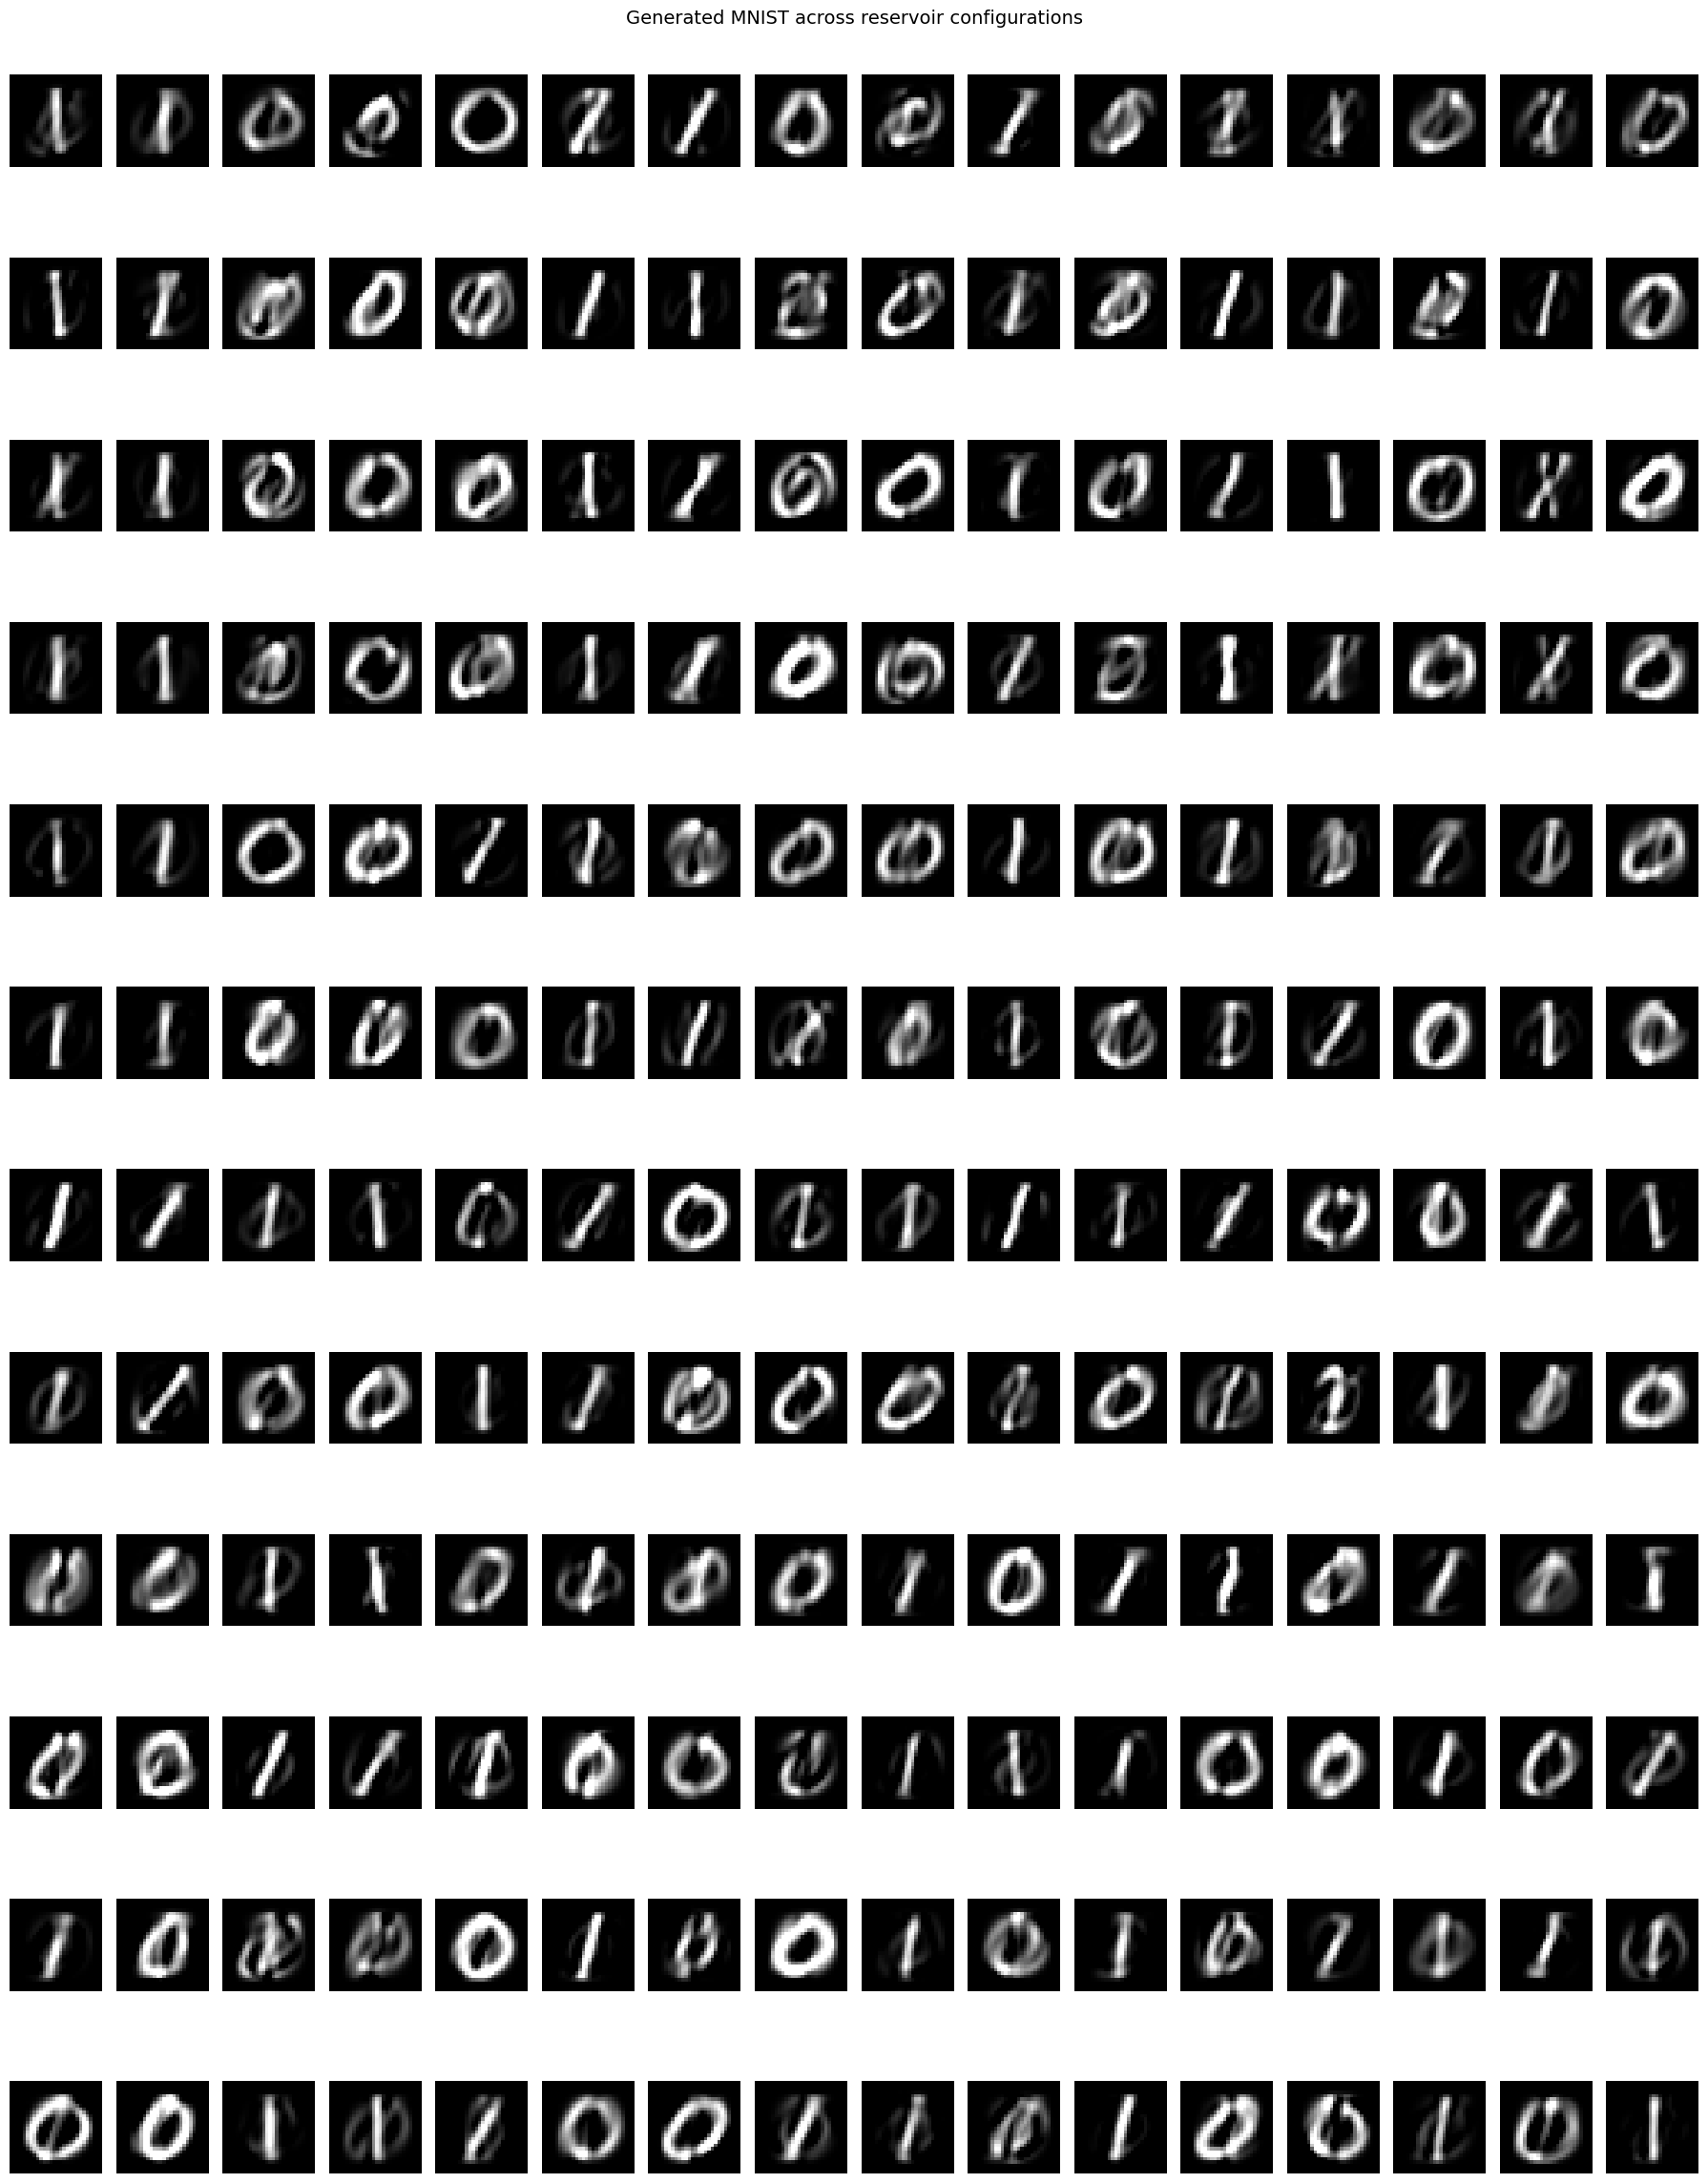

In [15]:
n_configs = len(configs)
fig, axes = plt.subplots(n_configs, 16, figsize=(18, 2 * n_configs))

for row, (D_s, K_s) in enumerate(configs):
    fl, gen_img = sweep_results[(D_s, K_s)]
    for col in range(16):
        axes[row, col].imshow(gen_img[col].reshape(28, 28), cmap='gray')
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(f'D={D_s}\nK={K_s}', fontsize=10, rotation=0,
                            labelpad=50, va='center')

plt.suptitle('Generated MNIST across reservoir configurations', fontsize=14)
plt.tight_layout()
plt.savefig('mnist_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

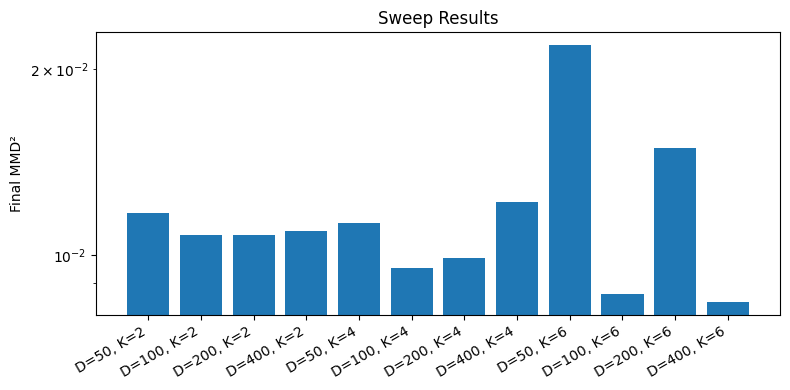

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
labels = [f'D={d}, K={k}' for d, k in configs]
vals = [sweep_results[c][0] for c in configs]
ax.bar(range(len(configs)), vals, tick_label=labels)
ax.set_ylabel('Final MMD²')
ax.set_title('Sweep Results')
ax.set_yscale('log')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('mnist_sweep_bar.png', dpi=150, bbox_inches='tight')
plt.show()